# Support Vector Machine (SVM)

This notebook demonstrates the core intuition behind linear SVM classification using a simple two-class dataset.

## What You Will See

- Two separable classes in 2D
- Multiple possible separating lines
- The maximum-margin decision boundary chosen by SVM
- Support vectors that define the boundary
- Classification of a new sample point

## Key Idea

SVM selects the separating boundary that maximizes the margin between classes, improving robustness and generalization.

In [1]:
%pip install -q numpy matplotlib scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Dark theme styling — matching the tutorial series
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',
    'axes.labelcolor': 'white',
    'xtick.color': 'white',
    'ytick.color': 'white',
    'text.color': 'white',
    'grid.color': '#21262d',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 12,
})

np.random.seed(42)
print("✅ Libraries imported and dark theme applied!")

Note: you may need to restart the kernel to use updated packages.
✅ Libraries imported and dark theme applied!


## Data Visualization

The plot below shows a small linearly separable dataset with two classes: apples and oranges.

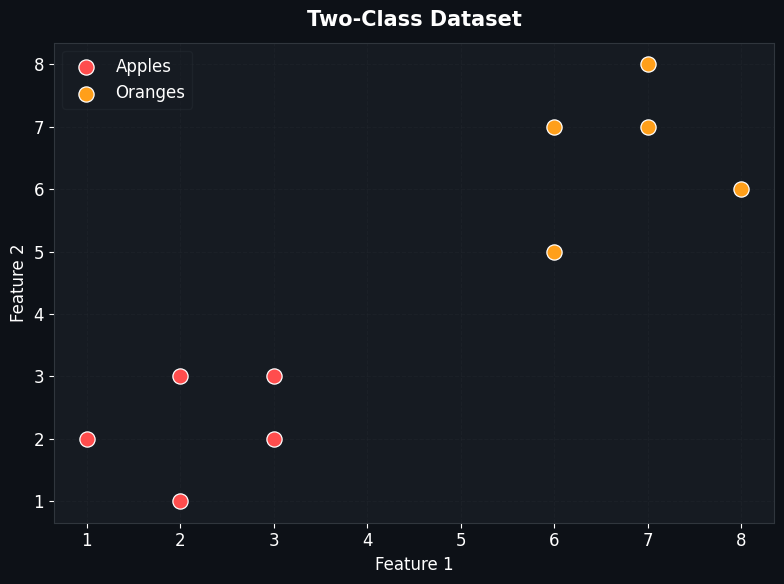

In [2]:
# Data points for two classes
X = np.array([
    [1, 2], [2, 3], [3, 3], [2, 1], [3, 2],
    [6, 5], [7, 7], [8, 6], [7, 8], [6, 7]
])
y = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#ff4d4d', s=120, edgecolors='white',
           linewidths=0.9, label='Apples', zorder=3)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#ff9f1a', s=120, edgecolors='white',
           linewidths=0.9, label='Oranges', zorder=3)
ax.set_title('Two-Class Dataset', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(framealpha=0.3, edgecolor='#30363d')
ax.grid(True)
plt.tight_layout()
plt.show()

## Decision Boundary and Margin

Many lines can separate these classes, but SVM chooses the boundary with the largest margin.

- Solid line: optimal decision boundary
- Dashed lines: margin boundaries
- Shaded region: margin width

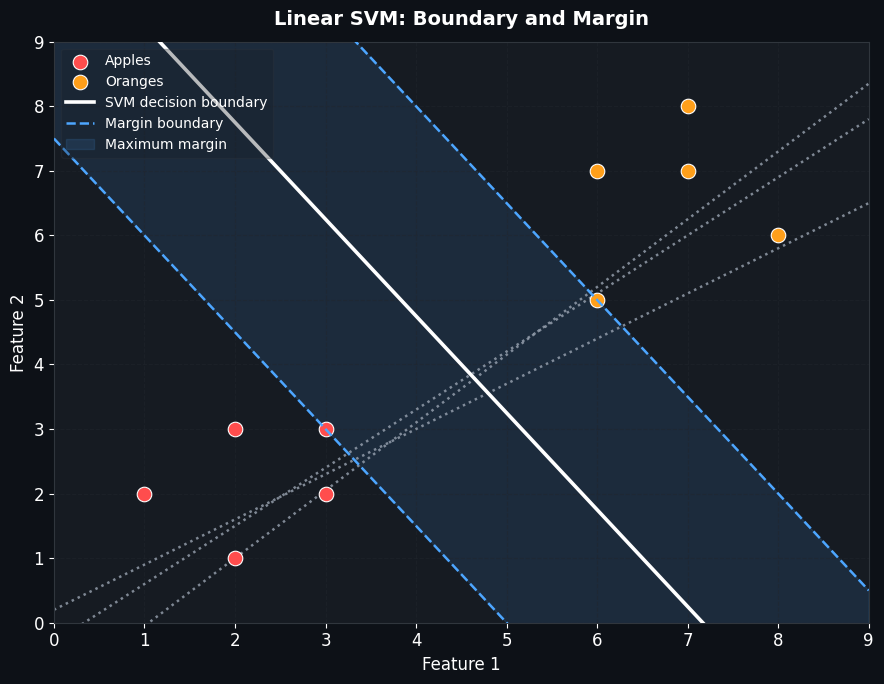

In [3]:
# Fit linear SVM and visualize boundary with maximum margin
model = SVC(kernel='linear', C=10)
model.fit(X, y)

x_line = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)

fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#ff4d4d', s=110, edgecolors='white', linewidths=0.8, label='Apples', zorder=3)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#ff9f1a', s=110, edgecolors='white', linewidths=0.8, label='Oranges', zorder=3)

# Example valid separating lines (not optimal)
for m, b in [(0.7, 0.2), (0.9, -0.3), (1.05, -1.1)]:
    ax.plot(x_line, m * x_line + b, linestyle=':', linewidth=1.8, color='#9aa4b2', alpha=0.8)

# SVM decision boundary and margin boundaries
w = model.coef_[0]
b = model.intercept_[0]
svm_line = -(w[0] * x_line + b) / w[1]
margin_up = -(w[0] * x_line + b - 1) / w[1]
margin_dn = -(w[0] * x_line + b + 1) / w[1]

ax.plot(x_line, svm_line, color='white', linewidth=2.6, label='SVM decision boundary', zorder=5)
ax.plot(x_line, margin_up, '--', color='#4da6ff', linewidth=1.8, label='Margin boundary', zorder=4)
ax.plot(x_line, margin_dn, '--', color='#4da6ff', linewidth=1.8, zorder=4)

ax.fill_between(x_line, margin_up, margin_dn, color='#4da6ff', alpha=0.12, label='Maximum margin')

ax.set_title('Linear SVM: Boundary and Margin', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
ax.set_ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
ax.legend(framealpha=0.3, edgecolor='#30363d', fontsize=10, loc='upper left')
ax.grid(True)
plt.tight_layout()
plt.show()

## Support Vectors

Support vectors are the closest training points to the boundary. They are the points that determine the final position of the SVM hyperplane.

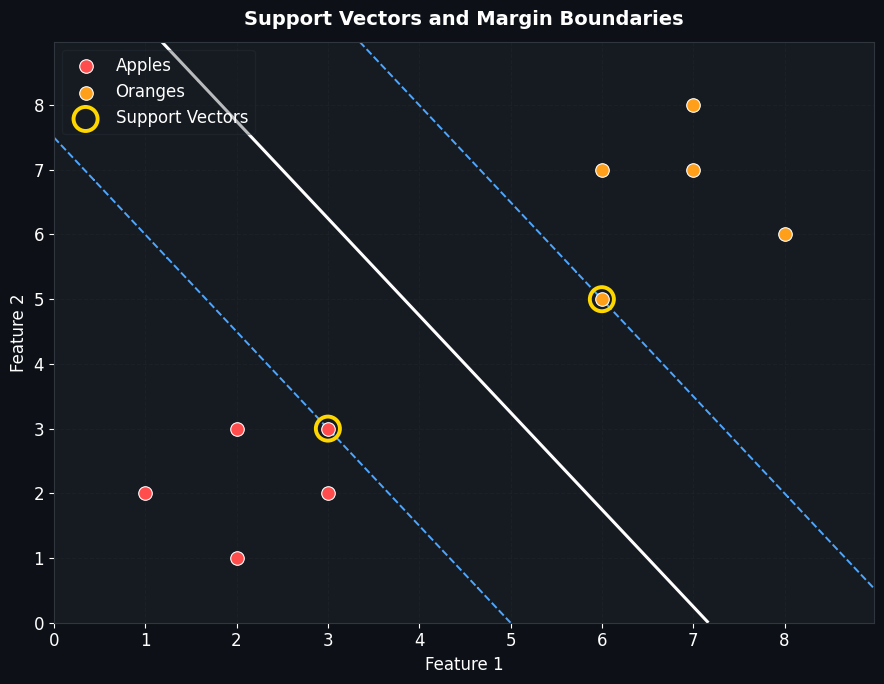

Support vector indices: [2, 5]


In [4]:
# Highlight support vectors
h = 0.02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z_dec = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(9, 7))
ax.contour(xx, yy, Z_dec, levels=[-1, 0, 1],
           linestyles=['--', '-', '--'],
           linewidths=[1.4, 2.2, 1.4],
           colors=['#4da6ff', 'white', '#4da6ff'])

ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#ff4d4d', s=95, edgecolors='white', linewidths=0.8, label='Apples', zorder=4)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#ff9f1a', s=95, edgecolors='white', linewidths=0.8, label='Oranges', zorder=4)

ax.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1],
           s=300, facecolors='none', edgecolors='#ffd700', linewidths=2.8,
           label='Support Vectors', zorder=5)

ax.set_title('Support Vectors and Margin Boundaries', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(framealpha=0.3, edgecolor='#30363d')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f'Support vector indices: {model.support_.tolist()}')

## New Point Classification

A new point is classified by checking which side of the decision boundary it falls on.

- Positive side: one class
- Negative side: the other class
- Distance from boundary: decision confidence

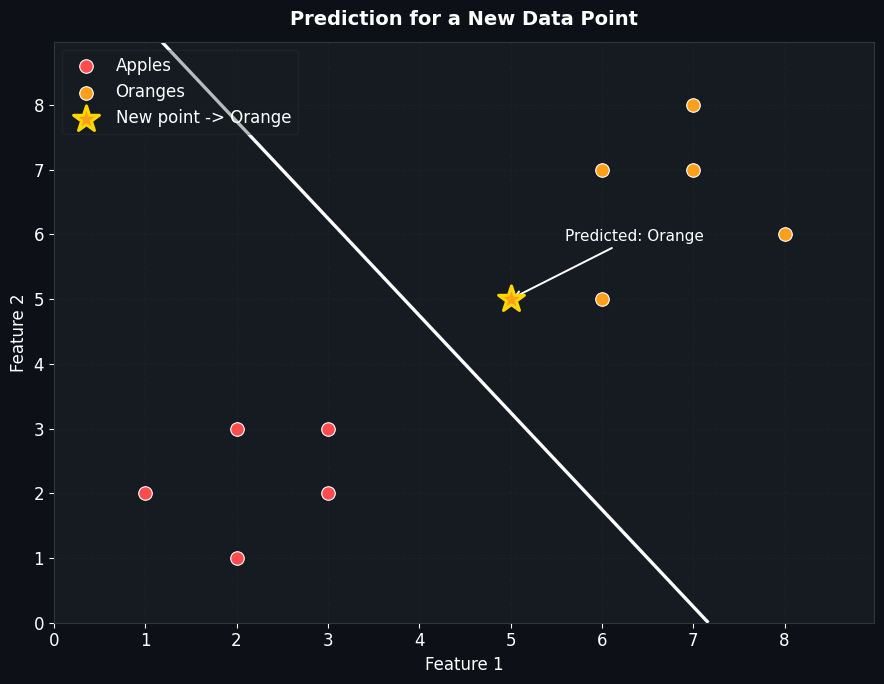

Decision score: +0.5385  ->  Predicted class: Orange


In [5]:
# Classify a new point using the trained SVM
new_point = np.array([[5.0, 5.0]])
prediction = model.predict(new_point)[0]
score = model.decision_function(new_point)[0]

fig, ax = plt.subplots(figsize=(9, 7))
ax.contour(xx, yy, Z_dec, levels=[0], colors=['white'], linewidths=[2.4])

ax.scatter(X[y == 0, 0], X[y == 0, 1], c='#ff4d4d', s=95, edgecolors='white', linewidths=0.8, label='Apples', zorder=3)
ax.scatter(X[y == 1, 0], X[y == 1, 1], c='#ff9f1a', s=95, edgecolors='white', linewidths=0.8, label='Oranges', zorder=3)

pred_color = '#ff4d4d' if prediction == 0 else '#ff9f1a'
label = 'Apple' if prediction == 0 else 'Orange'
ax.scatter(new_point[:, 0], new_point[:, 1], c=pred_color, s=380, marker='*',
           edgecolors='#ffd700', linewidths=2.2, label=f'New point -> {label}', zorder=6)

ax.annotate(f'Predicted: {label}',
            xy=(new_point[0, 0], new_point[0, 1]),
            xytext=(new_point[0, 0] + 0.6, new_point[0, 1] + 0.9),
            arrowprops=dict(arrowstyle='->', color='white', lw=1.4),
            fontsize=11, color='white')

ax.set_title('Prediction for a New Data Point', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.legend(framealpha=0.3, edgecolor='#30363d')
ax.grid(True)
plt.tight_layout()
plt.show()

print(f'Decision score: {score:+.4f}  ->  Predicted class: {label}')

## Summary

SVM combines three ideas:

- Best separating boundary
- Maximum margin
- Support vectors

**SVM = Best Separating Line + Maximum Margin + Support Vectors**

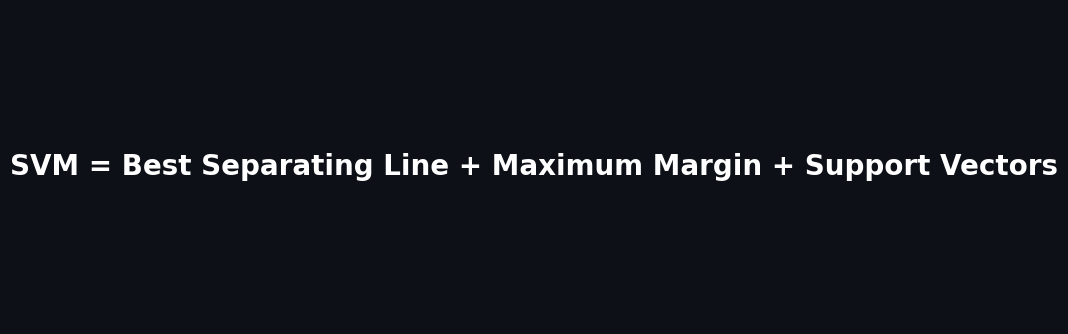

In [6]:
# Ending visual: keep this on screen for the last seconds
fig, ax = plt.subplots(figsize=(11, 3.5))
ax.axis('off')

final_text = 'SVM = Best Separating Line + Maximum Margin + Support Vectors'
ax.text(0.5, 0.5, final_text,
        ha='center', va='center', fontsize=20, fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## Run Order

1. Setup and imports
2. Data visualization
3. Decision boundary and margin
4. Support vector visualization
5. New point classification
6. Final summary visual